# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

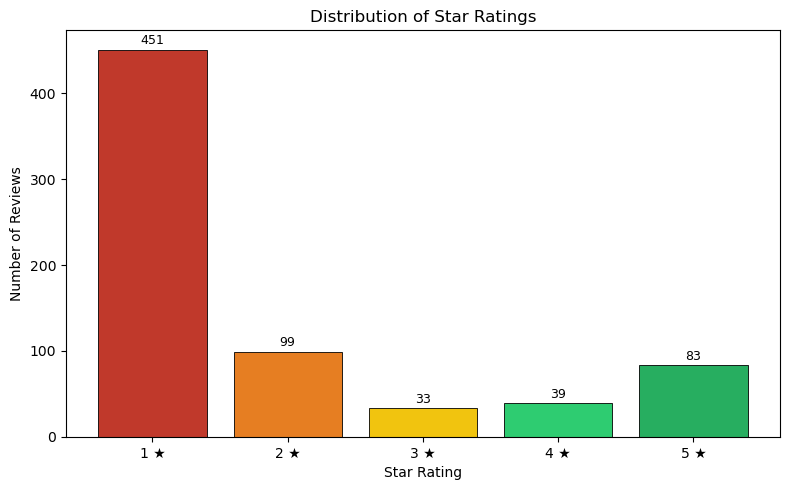

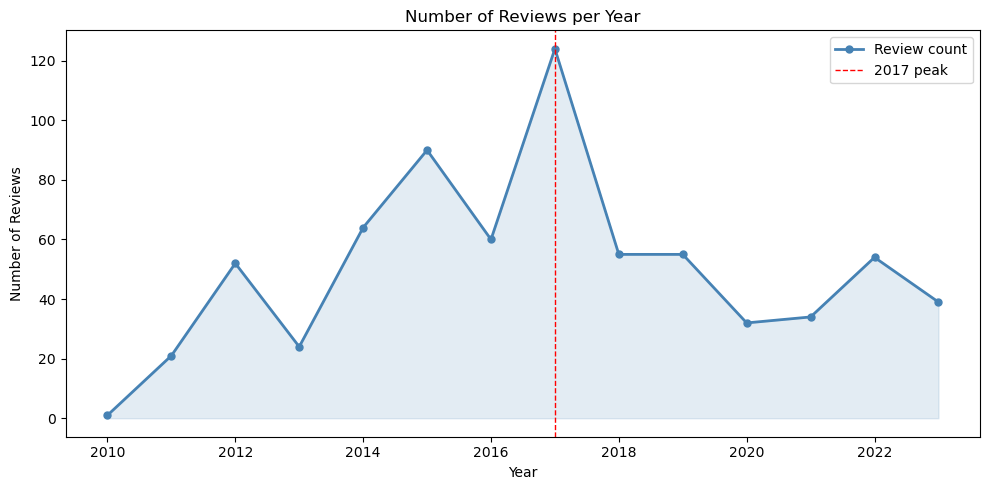

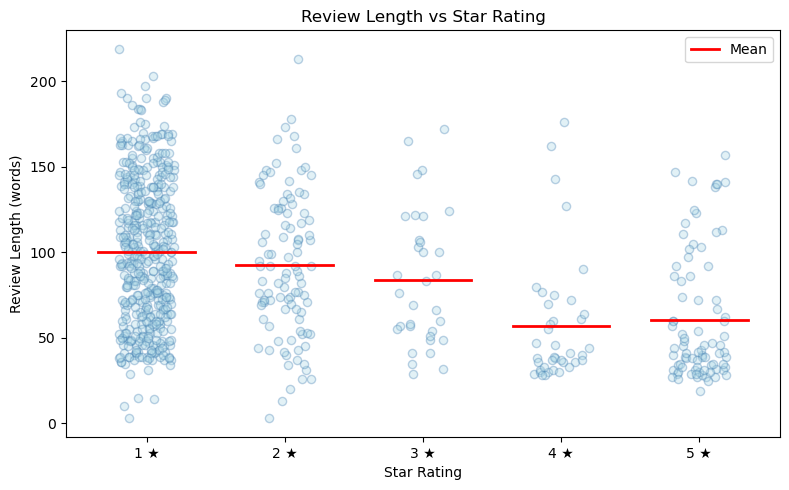

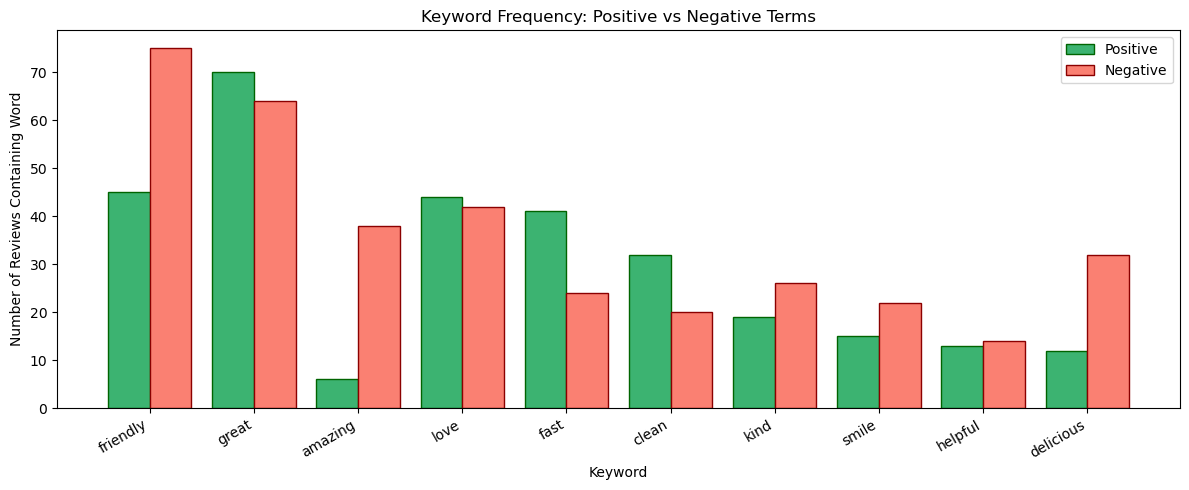

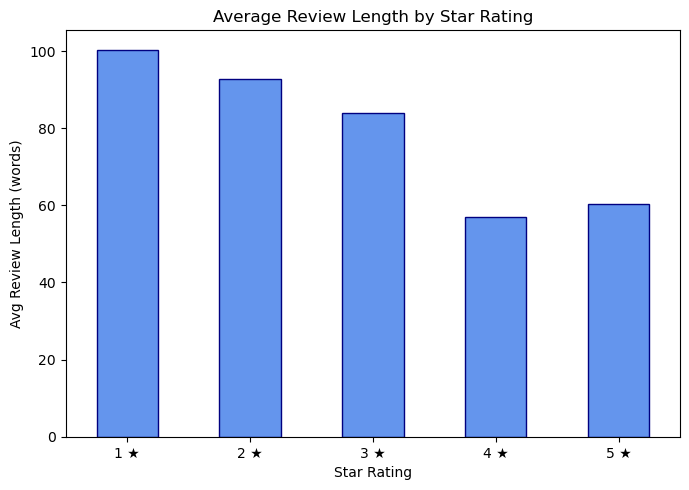

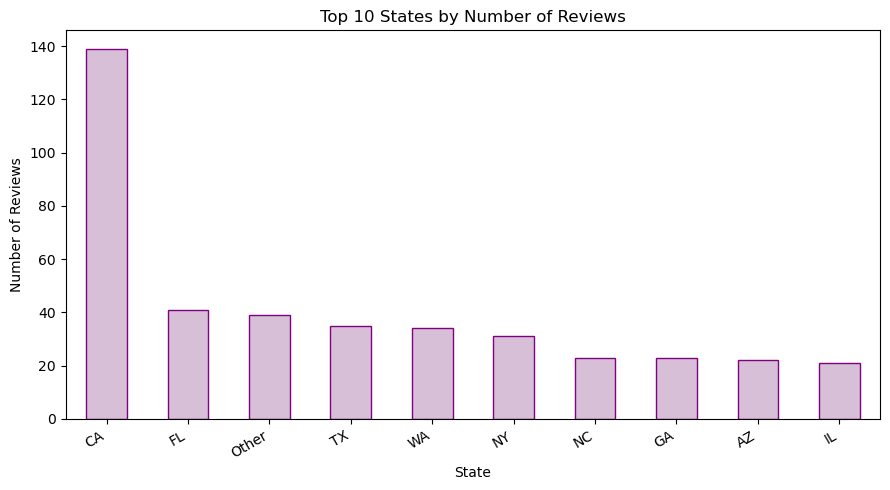

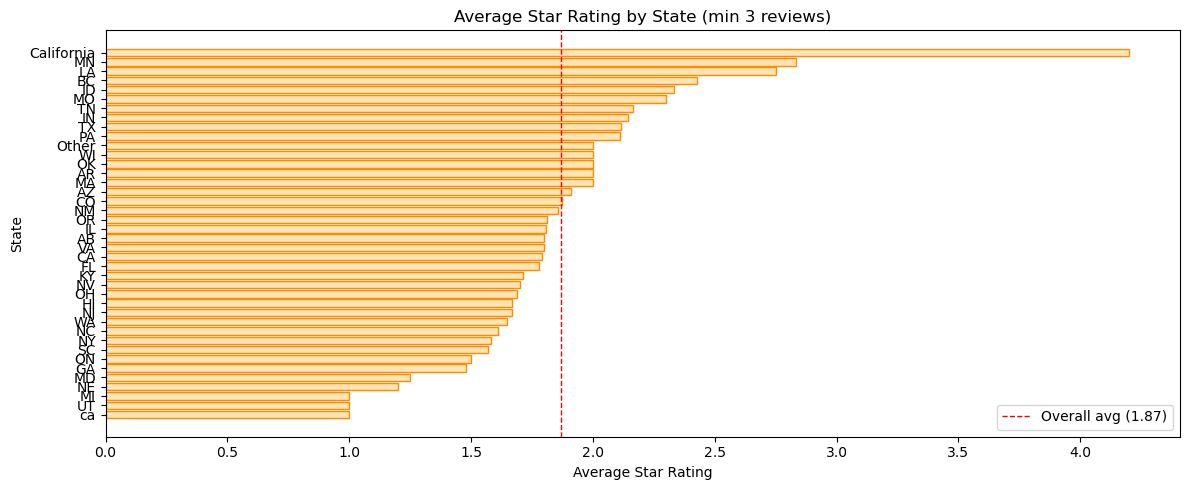

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Starbucks_reviews.csv')
df.columns = df.columns.str.strip().str.lstrip('\ufeff')

df = df[df['Rating'] != 'N/A'].copy()
df = df.dropna(subset=['Rating'])
df['Rating'] = df['Rating'].astype(int)
df['Year'] = df['Date'].str.extract(r'(\d{4})')[0].astype(float)
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df['State'] = df['location'].str.split(',').str[-1].str.strip()
df['ReviewLength'] = df['Review'].astype(str).apply(lambda x: len(x.split()))

rating_counts = df['Rating'].value_counts().sort_index()
colors = ['#c0392b', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

plt.figure(figsize=(8, 5))
bars = plt.bar(rating_counts.index, rating_counts.values,
               color=colors, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=9)
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks([1, 2, 3, 4, 5], ['1 ★', '2 ★', '3 ★', '4 ★', '5 ★'])
plt.tight_layout()
plt.show()

yearly = df.groupby('Year').size()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='steelblue',
         linewidth=2, markersize=5, label='Review count')
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
plt.axvline(x=2017, color='red', linestyle='--', linewidth=1, label='2017 peak')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.show()

jitter = np.random.uniform(-0.2, 0.2, size=len(df))

plt.figure(figsize=(8, 5))
plt.scatter(df['Rating'] + jitter, df['ReviewLength'],
            alpha=0.35, edgecolors='steelblue', facecolors='lightblue', s=35)
for r in [1, 2, 3, 4, 5]:
    avg = df[df['Rating'] == r]['ReviewLength'].mean()
    plt.plot([r - 0.35, r + 0.35], [avg, avg], color='red',
             linewidth=2, label='Mean' if r == 1 else '')
plt.title('Review Length vs Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Review Length (words)')
plt.xticks([1, 2, 3, 4, 5], ['1 ★', '2 ★', '3 ★', '4 ★', '5 ★'])
plt.legend()
plt.tight_layout()
plt.show()

positive_words = ['friendly', 'great', 'amazing', 'love', 'fast',
                  'clean', 'kind', 'smile', 'helpful', 'delicious']
negative_words = ['wait', 'rude', 'wrong', 'bad', 'cold',
                  'slow', 'worst', 'horrible', 'terrible', 'poor']

def count_keyword(word):
    return df['Review'].str.lower().str.contains(word).sum()

pos_counts = [count_keyword(w) for w in positive_words]
neg_counts = [count_keyword(w) for w in negative_words]

x = np.arange(len(positive_words))
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, pos_counts, width, label='Positive', color='mediumseagreen', edgecolor='darkgreen')
plt.bar(x + width / 2, neg_counts, width, label='Negative', color='salmon', edgecolor='darkred')
plt.xticks(x, positive_words, rotation=30, ha='right')
plt.title('Keyword Frequency: Positive vs Negative Terms')
plt.xlabel('Keyword')
plt.ylabel('Number of Reviews Containing Word')
plt.legend()
plt.tight_layout()
plt.show()

avg_length = df.groupby('Rating')['ReviewLength'].mean()

plt.figure(figsize=(7, 5))
avg_length.plot(kind='bar', color='cornflowerblue', edgecolor='navy')
plt.title('Average Review Length by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Avg Review Length (words)')
plt.xticks([0, 1, 2, 3, 4], ['1 ★', '2 ★', '3 ★', '4 ★', '5 ★'], rotation=0)
plt.tight_layout()
plt.show()

top_states = df['State'].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_states.plot(kind='bar', color='thistle', edgecolor='purple')
plt.title('Top 10 States by Number of Reviews')
plt.xlabel('State')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

state_stats = df.groupby('State').agg(avg_rating=('Rating', 'mean'),
                                       count=('Rating', 'count'))
state_stats = state_stats[state_stats['count'] >= 3].sort_values('avg_rating')

plt.figure(figsize=(12, 5))
plt.barh(state_stats.index, state_stats['avg_rating'],
         color='moccasin', edgecolor='darkorange')
plt.axvline(x=df['Rating'].mean(), color='red', linestyle='--',
            linewidth=1, label=f'Overall avg ({df["Rating"].mean():.2f})')
plt.title('Average Star Rating by State (min 3 reviews)')
plt.xlabel('Average Star Rating')
plt.ylabel('State')
plt.legend()
plt.tight_layout()
plt.show()